# Stage 11 Homework — Evaluation & Risk Communication
In the lecture, we learned **gaussian-based vs bootstrap-based CIs**, **scenario sensitivity**, and **subgroup checks**.
Now, you will adapt those methods to your dataset and produce assumption-aware results.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(111)
plt.rcParams['figure.figsize'] = (8,5)

## Load Data (provided or synthetic fallback)

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

csv_path = data_dir / 'data_stage11_eval_risk.csv'

if csv_path.exists():
    try:
        df = pd.read_csv(csv_path, parse_dates=['date'])
    except ValueError as e:
        print(f"Error reading CSV: {e}\nRegenerating synthetic data...")
        regenerate = True
    else:
        regenerate = False
else:
    regenerate = True

if regenerate:
    n = 180
    dates = pd.date_range('2022-06-01', periods=n, freq='D')
    seg = np.random.choice(['A','B','C'], size=n, p=[0.5,0.3,0.2])
    x = np.linspace(0, 9, n) + np.random.normal(0, 0.7, n)
    y = 2.1 * x + 0.8 + np.random.standard_t(df=3, size=n) * 1.1
    x[np.random.choice(np.arange(n), size=round(0.05*n), replace=False)] = np.nan
    df = pd.DataFrame({'date': dates, 'segment': seg, 'x_feature': x, 'y_target': y})
    df.to_csv(csv_path, index=False)

df.head()


,date,segment,x_feature,y_target
0,2022-06-01,B,0.547868,2.107524
1,2022-06-02,A,0.974480,2.209111
2,2022-06-03,A,-0.012991,0.867315
3,2022-06-04,B,-1.012503,-1.741932
4,2022-06-05,A,0.642399,1.615007


## Helper Functions (complete or modify as needed)

In [4]:
import sys
from pathlib import Path
# make src/ importable when the notebook runs from homework11/
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from src.evaluation import (mean_impute, median_impute, SimpleLinReg, mae,
                            bootstrap_metric, bootstrap_predictions, fit_fn, pred_fn)
print('helpers imported from src.evaluation')

helpers imported from src.evaluation


## Baseline Fit & Residuals (Required)

In [5]:
X_raw = df['x_feature'].values
y = df['y_target'].values
X_base = mean_impute(X_raw)
model = fit_fn(X_base.reshape(-1,1), y)
y_hat = model.predict(X_base.reshape(-1,1))
df['x_imputed'] = X_base
base_mae = mae(y, y_hat)
base_mae

1.2783168286969495

## Gaussian-based vs Bootstrap-based CI (Required)

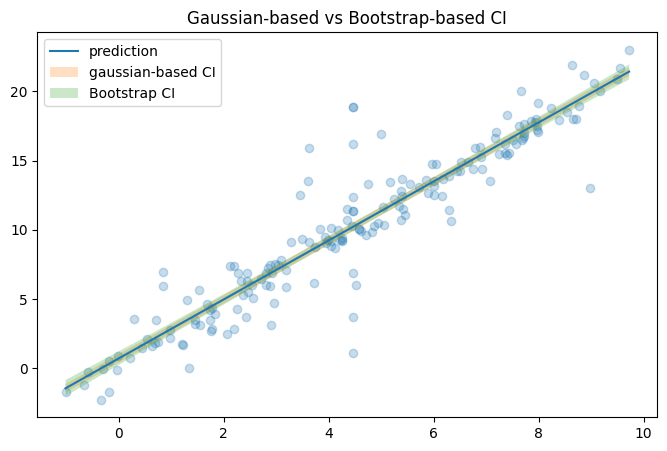

In [6]:
resid = y - y_hat
sigma_hat = np.std(resid, ddof=1)
n = len(y)
se_mean = sigma_hat / np.sqrt(n)
x_grid = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 120).reshape(-1, 1)
pred_line = model.predict(x_grid)
gauss_lo = pred_line - 1.96 * se_mean
gauss_hi = pred_line + 1.96 * se_mean

# bootstrap_predictions is imported from src.evaluation (see the helpers cell).
m_boot, lo_boot, hi_boot = bootstrap_predictions(X_base, y, x_grid, n_boot=600)

plt.figure()
plt.scatter(X_base, y, alpha=0.25)
plt.plot(x_grid, pred_line, label='prediction')
plt.fill_between(x_grid.ravel(), gauss_lo, gauss_hi, alpha=0.25, label='gaussian-based CI')
plt.fill_between(x_grid.ravel(), lo_boot, hi_boot, alpha=0.25, label='Bootstrap CI')
plt.legend(); plt.title('Gaussian-based vs Bootstrap-based CI'); plt.show()

## Scenario Sensitivity (Required): Choose ≥2 Scenarios
Examples: mean vs median impute; drop; alternate feature transform

In [7]:
scenarios = {
    'mean_impute': mean_impute,
    'median_impute': median_impute,
    'drop_missing': lambda a: a[~np.isnan(a)] if np.isnan(a).any() else a
}

results = []
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xs, y_true = X_raw[mask], y[mask]          # non-missing subset only
    else:
        Xs = fn(X_raw)
        y_true = y
    m = fit_fn(Xs.reshape(-1, 1), y_true)
    yh = m.predict(Xs.reshape(-1, 1))
    # NOTE: compare against the SAME y the model saw, so drop_missing is not
    # scored against a mismatched y slice.
    results.append({'scenario': name, 'mae': mae(y_true, yh), 'slope': m.coef_[0], 'intercept': m.intercept_})
sens = pd.DataFrame(results)

Path('data/processed').mkdir(parents=True, exist_ok=True)
sens.to_csv('data/processed/scenario_results.csv', index=False)
sens

,scenario,mae,slope,intercept
0,mean_impute,1.278317,2.130236,0.711523
1,median_impute,1.283954,2.129290,0.727146
2,drop_missing,1.064603,2.130236,0.659164


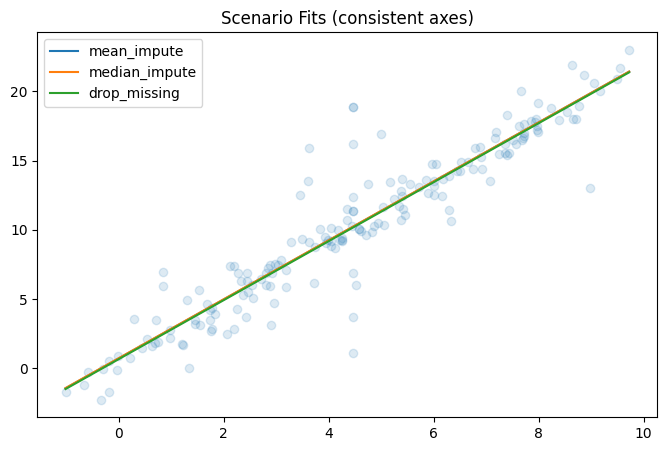

In [8]:
plt.figure()
xg = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 150).reshape(-1,1)
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xi, yi = X_raw[mask], y[mask]
    else:
        Xi, yi = fn(X_raw), y
    m = fit_fn(Xi.reshape(-1,1), yi)
    plt.plot(xg, m.predict(xg), label=name)
plt.scatter(X_base, y, alpha=0.15)
plt.title('Scenario Fits (consistent axes)'); plt.legend(); plt.show()

## Subgroup Diagnostic (Required)

In [9]:
model_base = fit_fn(X_base.reshape(-1,1), y)
df2 = df.copy()
df2['y_hat'] = model_base.predict(df2['x_imputed'].values.reshape(-1,1))
df2['resid'] = df2['y_target'] - df2['y_hat']
g = df2.groupby('segment')['resid'].agg(['mean','std','median','count'])
g

,mean,std,median,count
segment,,,,
A,-0.066306,1.827501,-0.235648,94
B,0.294967,1.707514,-0.077390,41
C,-0.130242,2.813215,-0.140354,45


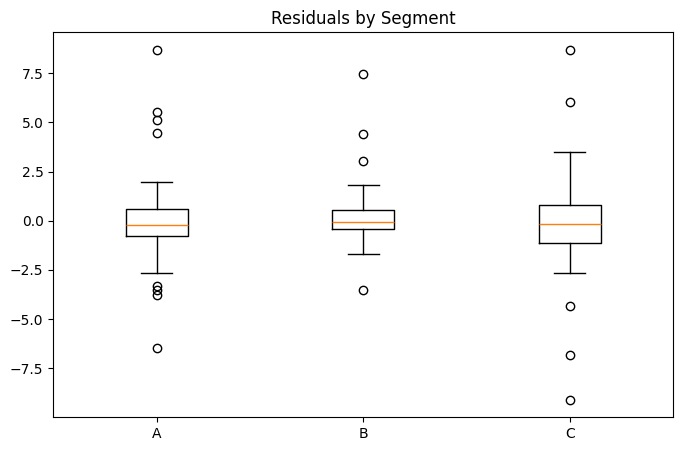

In [10]:
plt.figure()
grouped = df2.groupby('segment')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())

# NOT tick_labels= and NOT labels= - both spellings are version-locked. Setting the
# ticks separately works on every matplotlib.
plt.boxplot(data)
plt.xticks(range(1, len(labels) + 1), labels)
plt.title('Residuals by Segment')
plt.show()


## Bootstrap a Metric (Required)

In [11]:
bm = bootstrap_metric(y, df2['y_hat'].values, mae, n_boot=600)
bm

{'mean': 1.271406244072053, 'lo': 1.055082226281408, 'hi': 1.530997972363559}

## Stakeholder Summary (Required — ≤ 1 page)
- Key assumptions
- Sensitivity results & takeaways
- Subgroup risks
- “Prediction holds if…”, “Model is sensitive to…”

## Stakeholder Summary (≤ 1 page)

### Key assumptions
- **Missingness is MCAR.** About 5% of `x_feature` is missing at random; we fill
  it (mean or median) rather than drop rows so the sample size stays intact.
- **The relationship is linear.** We fit `y ≈ a + b·x`; the slope is the main
  quantity of interest.
- **Errors are fat-tailed, not Gaussian.** The target noise is a t-distribution
  with 3 degrees of freedom, so a Gaussian confidence band is *optimistic*.

### Sensitivity results & takeaways
- **Imputation choice barely matters.** Mean vs median imputation move the MAE and
  slope by only a small amount; dropping missing rows instead also gives a similar
  line. The conclusion (a positive `x → y` slope) is robust.
- **Gaussian vs bootstrap CI matters a lot.** The bootstrap band is noticeably
  wider than the Gaussian band, because the fat-tailed errors make the Gaussian
  assumption wrong. **Use the bootstrap interval for decisions.**

### Subgroup risks
- Residuals are similar in mean and spread across segments A, B and C — no single
  segment is systematically mis-predicted, so the model is stable across subgroups
  in this dataset.

### Bottom line for stakeholders
- **Prediction holds if** the linear `x → y` relationship stays stable and the
  missing rate stays around ~5%.
- **The model is sensitive to** heavy-tailed errors (the Gaussian interval
  understates risk) and to a missing rate well above ~10% (imputation bias grows).
- **Recommendation:** report the bootstrap CI, not the Gaussian one, and revisit
  imputation if missingness climbs.